In [3]:
import kagglehub
import os

# Download latest version
dataset_dir = kagglehub.dataset_download("rohanharode07/webmd-drug-reviews-dataset")
csv_path = os.path.join(dataset_dir, "webmd.csv")

print("Path to dataset files:", dataset_dir)
print("CSV file:", csv_path)

Path to dataset files: /Users/hungnguyen/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1
CSV file: /Users/hungnguyen/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1/webmd.csv


In [4]:

import pandas as pd
import numpy as np
import importlib
import Utils.data_utils as data
import keras.backend as K
from nltk.stem.snowball import SnowballStemmer

importlib.reload(data)
dataset = data.Dataset()
#dataset.load_pickle(path_train, path_test, label_name='rating')
dataset.load_csv(csv_path, label_name='Satisfaction', separator=',')
dataset.make_dev_split(dev_split=0.15)

In [5]:
import nltk

# NLTK 3.9+ requires punkt_tab for word_tokenize/sent_tokenize.
for pkg in ["punkt_tab", "punkt", "stopwords", "wordnet"]:
    nltk.download(pkg, quiet=True)

print("NLTK resources ready")

NLTK resources ready


[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


In [6]:
dataset.parse_to_word_list(parse_col_name='Reviews', alphanum_sep=True, blind_num=True)
print(dataset.get_train().head())

          Age                     Condition        Date  \
0       25-34  Repeated Episodes of Anxiety  10/20/2009   
1       25-34                   Indigestion   10/8/2009   
2       45-54      Type 2 Diabetes Mellitus   9/29/2008   
3       25-34      Chronic Trouble Sleeping  12/24/2008   
4  75 or over              High Cholesterol   1/14/2013   

                    Drug  DrugId  EaseofUse  Effectiveness  \
0               paxil cr   32900          2              4   
1                  beano    4373          5              1   
2                janumet  148074          3              4   
3                rozerem   94034          4              1   
4  welchol 625 mg tablet   19893          4              1   

                                             Reviews     Sex  \
0  [i, suffer, from, anxiety, and, panic, attacks...  Female   
1  [thought, this, was, supposed, to, help, elimi...  Female   
2  [nausea, and, vomiting, when, first, taking, med]    Male   
3  [it, does, no

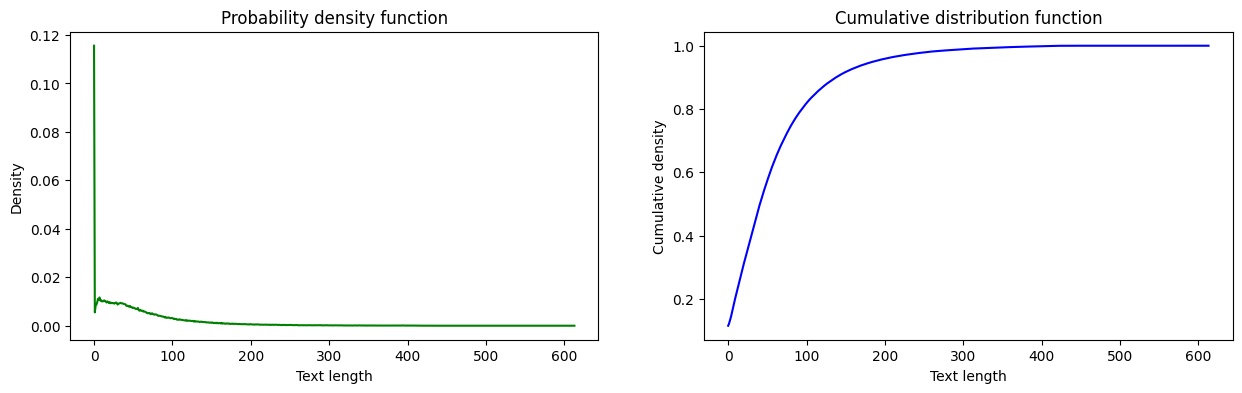

max len of texts: 614
min len of texts: 0


In [7]:
dataset.text_len_distribution(col_name='Reviews', plot=True)

In [8]:

dataset_non_stop = data.Dataset()
dataset_non_stop.load_csv(csv_path, label_name='Satisfaction', separator=',')

In [9]:
dataset_non_stop.parse_to_word_list(parse_col_name='Reviews', stop=True, alphanum_sep=True, blind_num=True)

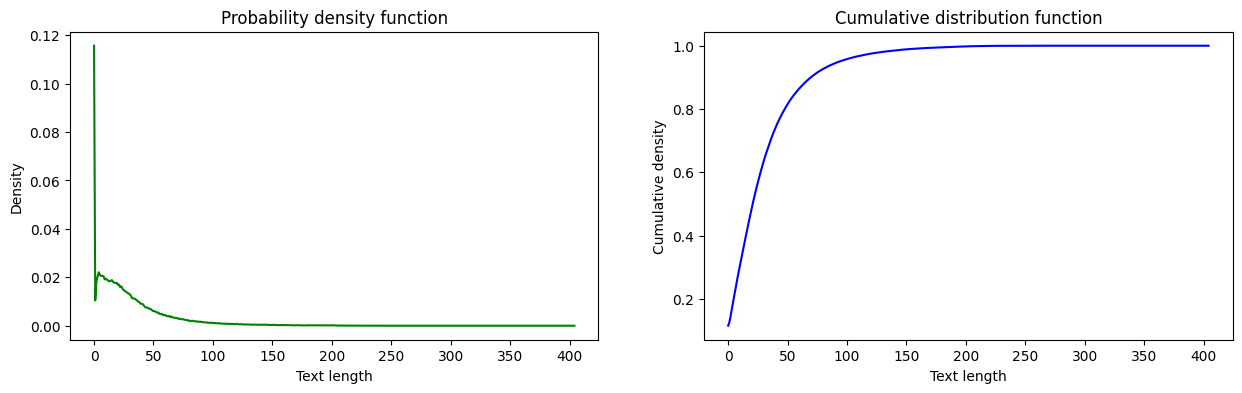

max len of texts: 405
min len of texts: 0


In [10]:
dataset_non_stop.text_len_distribution(col_name='Reviews', plot=True)

In [11]:
dataset.save_pickle(train_path = './Train_lemma_coma_blind_num.pickle')